Principios de Machine Learning - (PML)
Proyecto Tarea de Regresion - Modelos Polinomiales y Regularizados

Diego Burbano

## 1. Importar las librerias necesarias para el modelo

In [ ]:
import pandas as pd

import matplotlib.pyplot as plt
from mlxtend.plotting import scatterplotmatrix

from mlxtend.plotting import heatmap
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, root_mean_squared_error, mean_absolute_error, r2_score

import os
from google.colab import drive

from importlib.metadata import version


Revisión de versiones:

In [ ]:
print(f"Versión de Pandas: {version('pandas')}")
print(f"Versión de Scikit-learn: {version('scikit-learn')}")

Versión de Pandas: 2.2.2
Versión de Scikit-learn: 1.6.1


## 2. Carga de Datos


In [ ]:
# En esta celda se esta montando el drive  que tiene almacenado los datos en la ruta MyDrive/datos
drive.mount('/content/drive', force_remount=True)

# una vez se montó el drive, se cambia la ruta de archivo de 'content' de Colab por la ruta de Google Drive ('/MyDrive/datos/')
os.chdir('/content/drive/MyDrive/datos/')

Mounted at /content/drive


In [ ]:
datos_sin_procesar = pd.read_csv('./Datos_Etapa-1.csv', sep=',')

Revisaremos los primeros datos del conjunto:

In [ ]:
datos_sin_procesar.head()

,season,weekday,weathersit,temp,atemp,hum,windspeed,cnt,time_of_day
0,Winter,6,Clear,3.28,3.0014,0.81,0.0,16,Night
1,Winter,6,Clear,2.34,1.9982,0.80,0.0,40,Night
2,Winter,6,Clear,2.34,1.9982,0.80,0.0,32,Night
3,Winter,6,Clear,3.28,3.0014,0.75,0.0,13,Night
4,Winter,6,Clear,3.28,3.0014,0.75,0.0,1,Night


In [ ]:
datos_sin_procesar.describe()

,weekday,temp,atemp,hum,windspeed,cnt
count,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,3.003683,15.358397,15.401157,0.627229,12.736540,189.463088
std,2.005771,9.050138,11.342114,0.192930,8.196795,181.387599
min,0.000000,-7.060000,-16.000000,0.000000,0.000000,1.000000
25%,1.000000,7.980000,5.997800,0.480000,7.001500,40.000000
50%,3.000000,15.500000,15.996800,0.630000,12.998000,142.000000
75%,5.000000,23.020000,24.999200,0.780000,16.997900,281.000000
max,6.000000,39.000000,50.000000,1.000000,56.996900,977.000000


## 3. Preparacion de los datos

### Eliminación de datos faltantes

Revisaremos si hay datos faltantes:

In [ ]:
datos_sin_procesar.isna().sum()

,0
season,0
weekday,0
weathersit,0
temp,0
atemp,0
hum,0
windspeed,0
cnt,0
time_of_day,0


No existen datos faltantes.

### Eliminacion de duplicados

Verificación de instancias duplicadas:

In [ ]:
datos_sin_procesar.duplicated().sum()

42

Existen 42 registros repetidos, los cuales eliminaremos.

In [ ]:
datos = datos_sin_procesar.drop_duplicates()

Verificamos que se hayan eliminado los registros:

In [ ]:
datos.count()

,0
season,17337
weekday,17337
weathersit,17337
temp,17337
atemp,17337
hum,17337
windspeed,17337
cnt,17337
time_of_day,17337


En el set sin procesar contabamos con 17379, ahora contamos con 17337; la diferencia nos arroja los 42 registros repetidos.

### Revision de relevancia de variables

In [ ]:
columnas = ['ESTACION', 'DIA', 'CLIMA', 'TEMP', 'SENSACION', 'HUMEDAD', 'VELOCIDAD', 'CANTIDAD', 'JORNADA']
datos.columns = columnas
datos.head()

,ESTACION,DIA,CLIMA,TEMP,SENSACION,HUMEDAD,VELOCIDAD,CANTIDAD,JORNADA
0,Winter,6,Clear,3.28,3.0014,0.81,0.0,16,Night
1,Winter,6,Clear,2.34,1.9982,0.80,0.0,40,Night
2,Winter,6,Clear,2.34,1.9982,0.80,0.0,32,Night
3,Winter,6,Clear,3.28,3.0014,0.75,0.0,13,Night
4,Winter,6,Clear,3.28,3.0014,0.75,0.0,1,Night


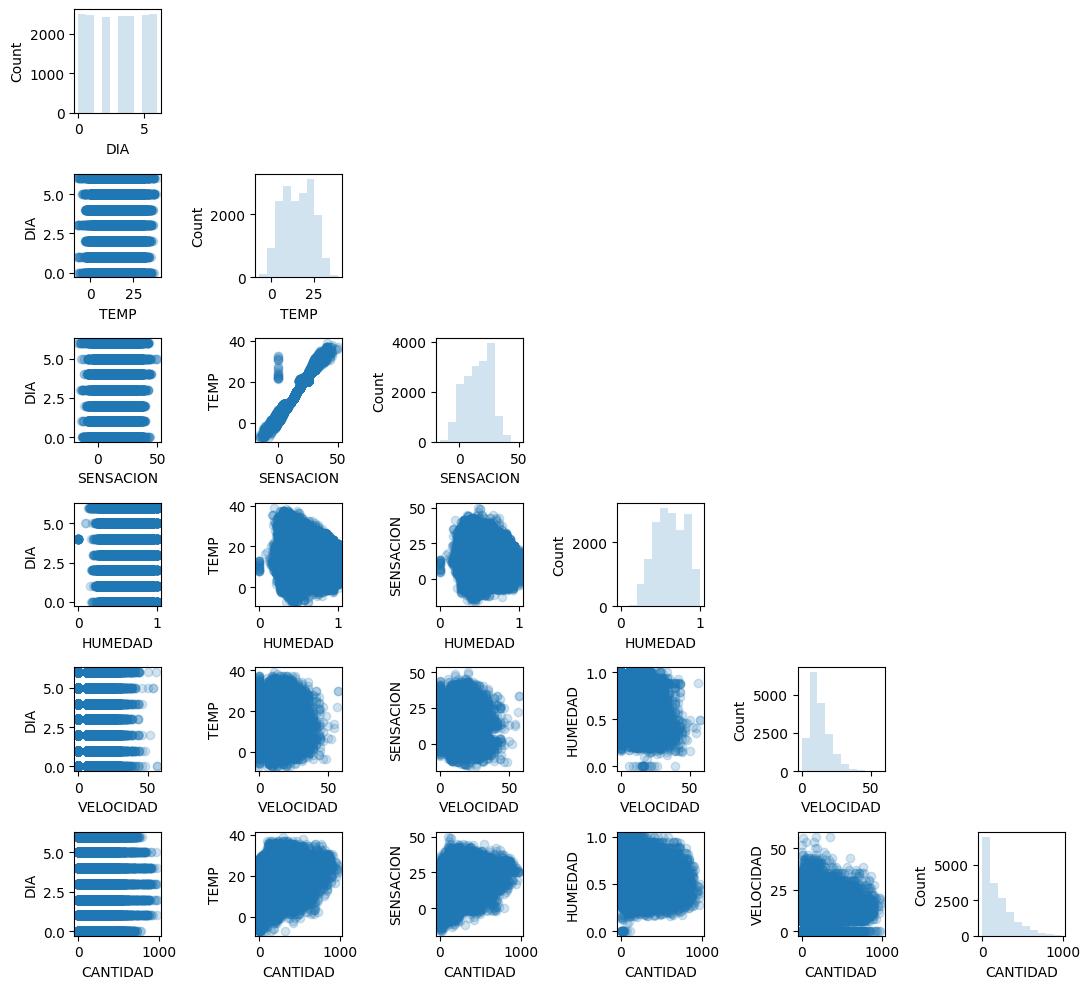

In [ ]:
variables_numericas = ['DIA', 'TEMP', 'SENSACION', 'HUMEDAD', 'VELOCIDAD', 'CANTIDAD']
scatterplotmatrix(datos[variables_numericas].values, figsize=(11, 10), names = variables_numericas, alpha = 0.2)
plt.tight_layout()
plt.show()

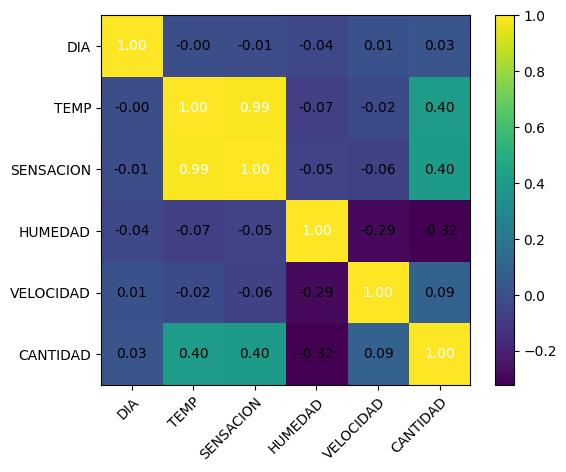

In [ ]:
cm = np.corrcoef(datos[variables_numericas].values.T)
hm = heatmap(cm,row_names=variables_numericas, column_names=variables_numericas)
plt.show()